In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
# Creiamo un semplice dataset di esempio
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([2, 4, 5, 4, 5])

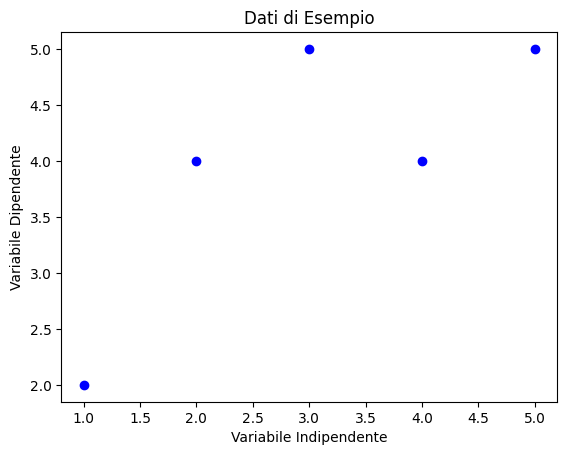

In [3]:
# Visualizziamo i dati
plt.scatter(X, y, color='blue')
plt.xlabel('Variabile Indipendente')
plt.ylabel('Variabile Dipendente')
plt.title('Dati di Esempio')
plt.show()

In [4]:
# Inizializziamo il modello di regressione lineare
model = LinearRegression()

# Addestriamo il modello sui dati
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [5]:
# Otteniamo l'intercetta e il coefficiente angolare
intercept = model.intercept_
coefficient = model.coef_[0]

print(f'Intercetta (β₀): {intercept}')
print(f'Coefficiente Angolare (β₁): {coefficient}')

Intercetta (β₀): 2.2
Coefficiente Angolare (β₁): 0.6


In [6]:
# Facciamo previsioni sui dati di input
y_pred = model.predict(X)
y_pred

array([2.8, 3.4, 4. , 4.6, 5.2])

In [7]:
from sklearn.metrics import mean_squared_error, r2_score

# Calcoliamo l'errore quadratico medio e 
# il coefficiente di determinazione
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f'Errore Quadratico Medio (MSE): {mse}')
print(f'Coefficiente di Determinazione (R²): {r2}')

Errore Quadratico Medio (MSE): 0.47999999999999987
Coefficiente di Determinazione (R²): 0.6000000000000001


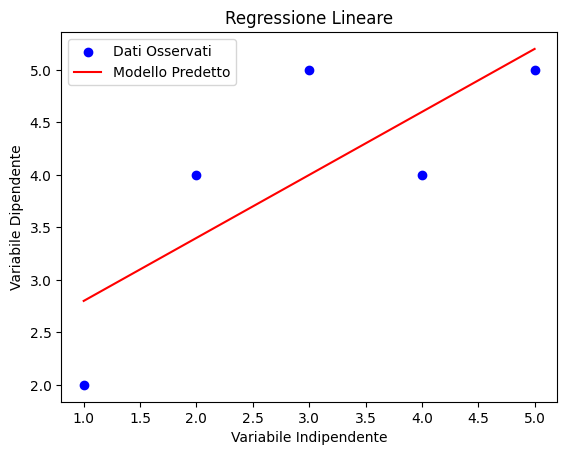

In [8]:
# Visualizziamo i risultati
plt.scatter(X, y, color='blue', label='Dati Osservati')
plt.plot(X, y_pred, color='red', label='Modello Predetto')
plt.xlabel('Variabile Indipendente')
plt.ylabel('Variabile Dipendente')
plt.title('Regressione Lineare')
plt.legend()
plt.show()

In [9]:
# Dataset con due variabili indipendenti
X_multi = np.array([[1, 2],
                    [2, 1],
                    [3, 0],
                    [4, -1],
                    [5, -2]])
y_multi = np.array([5, 4, 6, 8, 7])

# Inizializziamo e addestriamo il modello
model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)

# Otteniamo i coefficienti
intercept_multi = model_multi.intercept_
coefficients_multi = model_multi.coef_

print(f'Intercetta (β₀): {intercept_multi}')
print(f'Coefficiente β₁: {coefficients_multi[0]}')
print(f'Coefficiente β₂: {coefficients_multi[1]}')


Intercetta (β₀): 4.8
Coefficiente β₁: 0.4000000000000001
Coefficiente β₂: -0.4


In [10]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [11]:
# Caricamento del dataset
housing = fetch_california_housing(as_frame=True)
data = housing.frame
target = housing.target

In [12]:
print(housing)

{'data':        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -1

In [13]:
print(data)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  MedHouseVal  
0      

In [14]:
print(target)

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64


In [15]:
# Visualizzazione delle prime righe del dataset e delle sue colonne
print("Prime 5 righe del dataset:")
print(data.head())

Prime 5 righe del dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [16]:
print("\nInformazioni sulle colonne del dataset:")
print(data.info())


Informazioni sulle colonne del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [17]:
print("\nDescrizione delle statistiche del dataset:")
print(data.describe())


Descrizione delle statistiche del dataset:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532     

In [18]:
# Aggiungiamo la variabile target al DataFrame 
# per facilitare l'analisi delle correlazioni
data['MedHouseVal'] = target
data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [19]:
# Matrice di correlazione per vedere la 
# relazione tra le variabili
print("\nMatrice di correlazione:")
print(data.corr()['MedHouseVal'].sort_values(ascending=False))


Matrice di correlazione:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


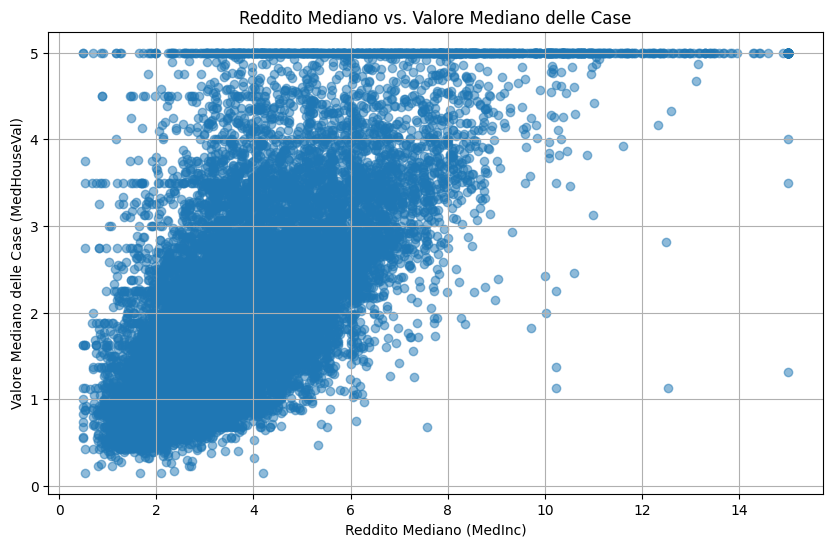

In [20]:
# Visualizzazione della relazione tra una variabile 
# indipendente e la variabile target
# Ad esempio, Useremo 'MedInc' (reddito mediano) che ha una 
# forte correlazione positiva
plt.figure(figsize=(10, 6))
plt.scatter(data['MedInc'], data['MedHouseVal'], alpha=0.5)
plt.title('Reddito Mediano vs. Valore Mediano delle Case')
plt.xlabel('Reddito Mediano (MedInc)')
plt.ylabel('Valore Mediano delle Case (MedHouseVal)')
plt.grid(True)
plt.show()

In [21]:
# Definiamo le variabili indipendenti (X) e dipendenti (y)
X = data.drop('MedHouseVal', axis=1) # Tutte le colonne tranne 'MedHouseVal'
y = data['MedHouseVal'] # La colonna 'MedHouseVal'


In [22]:
# Divisione del dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [23]:
print(f"\nDimensione del set di training: {X_train.shape[0]} samples")
print(f"Dimensione del set di test: {X_test.shape[0]} samples")


Dimensione del set di training: 16512 samples
Dimensione del set di test: 4128 samples


In [24]:
# Creazione del modello di regressione lineare
model = LinearRegression()

In [25]:
# Addestramento del modello sul set di training
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
# Visualizzazione dei coefficienti e dell'intercetta
print("\nCoefficienti del modello (m_i):")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"\nIntercetta del modello (b): {model.intercept_:.4f}")



Coefficienti del modello (m_i):
MedInc: 0.4487
HouseAge: 0.0097
AveRooms: -0.1233
AveBedrms: 0.7831
Population: -0.0000
AveOccup: -0.0035
Latitude: -0.4198
Longitude: -0.4337

Intercetta del modello (b): -37.0233


In [27]:
# Effettuare predizioni sul set di test
y_pred = model.predict(X_test)
y_pred

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251], shape=(4128,))

In [28]:
# Calcolo delle metriche di valutazione
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)

print(f"\nMean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")


Mean Squared Error (MSE): 0.5559
Root Mean Squared Error (RMSE): 0.7456
R-squared (R²): 0.5758


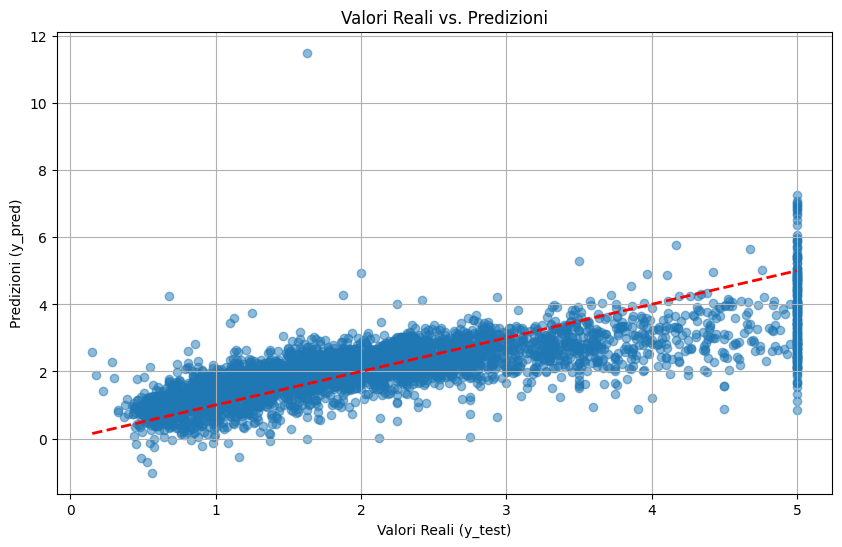

In [29]:
# Visualizzazione delle predizioni vs. valori reali
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Linea y=x
plt.title('Valori Reali vs. Predizioni')
plt.xlabel('Valori Reali (y_test)')
plt.ylabel('Predizioni (y_pred)')
plt.grid(True)
plt.show()